In [3]:
import signac
import matplotlib.pyplot as plt
import gsd.hoomd
import numpy as np
from scipy.stats import linregress

In [4]:
project = signac.get_project("/home/stephaniemccallu/scratch/Entanglements")

In [45]:
chain_lengths = []
D = []
fit_line = []
for length, jobs in project.find_jobs({"doc.sampled":True}).groupby("doc.lengths"):
    for job in jobs:
        if length < 250 and length != 150 and length != 100 and length > 30:
            time = np.load(job.fn("msd_time_bs_50_400.npy"))
            msd_nm = np.load(job.fn("msd_data_reduced_bs_50_400.npy"))
            #plt.plot(time[1:], msd_nm_5[1:], linewidth=3, label=length)
            slope, intercept, r_value, p_value, std_err = linregress(time[-133:-100], msd_nm[-133:-100])
            #plt.plot(np.log(length), np.log(slope*length),marker="o",linestyle="--",label=length) 
            print(r_value,length)
            fit_line.append([slope,intercept])
            chain_lengths.append(length)
            D.append(slope*length)

chain_lengths = np.array(chain_lengths)
D = np.array(D)

0.9966909605583854 50
0.9974040012681579 65
0.9955938553589432 75
0.9970874732284418 85
0.9900547552090239 125
0.9700835816674948 175
0.9359778692766095 200


In [46]:
n_cut = 125
line1_ind = np.where(np.array(chain_lengths) <= n_cut)[0]
line2_ind = np.where(np.array(chain_lengths) >= n_cut)[0]
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(chain_lengths[line1_ind], D[line1_ind])
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(chain_lengths[line2_ind], D[line2_ind])
line1_y = np.array(slope1*chain_lengths + intercept1)
line2_y = np.array(slope2*chain_lengths + intercept2)
print(r_value1, r_value2)

-0.9895491848389173 -0.9771797475924207


([<matplotlib.axis.XTick at 0x7f3c2fcbe890>,
 [Text(30, 0, '30'),
  Text(80, 0, '80'),
  Text(130, 0, '130'),
  Text(180, 0, '180')])

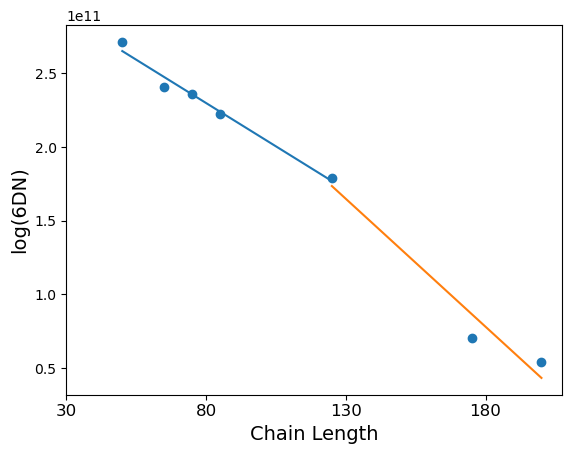

In [47]:
plt.scatter(chain_lengths,D,marker="o")  
plt.plot(chain_lengths[line1_ind], line1_y[line1_ind])
plt.plot(chain_lengths[line2_ind], line2_y[line2_ind])

#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Chain Length",fontsize=14)
plt.ylabel("log(6DN)",fontsize=14)
plt.xticks(np.arange(30,200,50),fontsize=12)
#plt.yticks(np.arange(24.5,27, 1.0),fontsize=12)

#plt.legend(title="N")
#plt.title("6DN")